# **Phase 1 Global Analysis — DAWN vs ACDC**

This notebook centralizes the **Phase 1 in-domain results** for the dissertation project:

- DAWN → DAWN
- ACDC → ACDC
- YOLOv11s vs Faster R-CNN
- Global and weather-specific evaluation

The objective is to compare both datasets and both architectures under the same Phase 1 protocol before moving to cross-dataset evaluation.

# **Mount Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Imports and global settings**

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

# **Path configuration**

In [ ]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Dissertation")

RESULTS_DIR = PROJECT_ROOT / "Results" / "phase1_global_analysis"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Results dir :", RESULTS_DIR)

Project root: /content/drive/MyDrive/Colab Notebooks/Dissertation
Results dir : /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis


# **Load DAWN and ACDC results**

In [ ]:
DAWN_RESULTS_PATH = PROJECT_ROOT / "Runs" / "comparisons" / "dawn_indomain_yolo_vs_fasterrcnn_seed42" / "dawn_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv"
ACDC_RESULTS_PATH = PROJECT_ROOT / "Runs" / "comparisons" / "acdc_indomain_yolo_vs_fasterrcnn_seed42" / "acdc_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv"

print("DAWN exists:", DAWN_RESULTS_PATH.exists(), DAWN_RESULTS_PATH)
print("ACDC exists:", ACDC_RESULTS_PATH.exists(), ACDC_RESULTS_PATH)

DAWN exists: True /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/dawn_indomain_yolo_vs_fasterrcnn_seed42/dawn_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv
ACDC exists: True /content/drive/MyDrive/Colab Notebooks/Dissertation/Runs/comparisons/acdc_indomain_yolo_vs_fasterrcnn_seed42/acdc_indomain_yolo_vs_fasterrcnn_seed42_comparison.csv


In [ ]:
def load_results(path, dataset_name):
    df = pd.read_csv(path)
    df["dataset"] = dataset_name
    return df

if not DAWN_RESULTS_PATH.exists():
    raise FileNotFoundError(f"DAWN file not found: {DAWN_RESULTS_PATH}")
if not ACDC_RESULTS_PATH.exists():
    raise FileNotFoundError(f"ACDC file not found: {ACDC_RESULTS_PATH}")

dawn_df = load_results(DAWN_RESULTS_PATH, "DAWN")
acdc_df = load_results(ACDC_RESULTS_PATH, "ACDC")

print("DAWN shape:", dawn_df.shape)
print("ACDC shape:", acdc_df.shape)

display(dawn_df.head())
display(acdc_df.head())

DAWN shape: (8, 10)
ACDC shape: (8, 11)


,split,model,mAP50-95,mAP50,mAP75,Precision,Recall,mAR100,FPS,dataset
0,global,YOLOv11s,0.339629,0.581245,NaN,0.577608,0.592754,NaN,80.284851,DAWN
1,global,Faster R-CNN,0.432050,0.655329,0.506732,NaN,NaN,NaN,20.323207,DAWN
2,fog,YOLOv11s,0.384665,0.615262,NaN,0.805451,0.562134,NaN,79.086144,DAWN
3,fog,Faster R-CNN,0.384682,0.599742,0.475654,NaN,NaN,NaN,20.329152,DAWN
4,rain,YOLOv11s,0.357261,0.542943,NaN,0.618243,0.573743,NaN,81.500717,DAWN


,split,model,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score,mAR100,FPS,dataset
0,global,YOLOv11s,0.332924,0.521167,0.345546,0.765000,0.441276,0.559700,NaN,84.532316,ACDC
1,global,Faster R-CNN,0.412798,0.596349,0.449924,NaN,NaN,NaN,NaN,16.103002,ACDC
2,fog,YOLOv11s,0.412664,0.627669,0.427248,0.858360,0.546958,0.668158,NaN,85.139722,ACDC
3,fog,Faster R-CNN,0.547244,0.754025,0.590740,NaN,NaN,NaN,NaN,16.166123,ACDC
4,rain,YOLOv11s,0.308140,0.483562,0.319447,0.766111,0.405806,0.530571,NaN,85.804685,ACDC


# **Harmonize columns**

In [ ]:
def harmonize_results(df):
    df = df.copy()

    # Standardize weather/condition column
    if "condition" not in df.columns:
        if "split" in df.columns:
            df = df.rename(columns={"split": "condition"})
        elif "weather" in df.columns:
            df = df.rename(columns={"weather": "condition"})
        else:
            raise ValueError("No condition/split/weather column found.")

    # Standardize model names
    df["model"] = df["model"].astype(str).str.strip()
    df["model"] = df["model"].replace({
        "YOLO": "YOLOv11s",
        "YOLOv11": "YOLOv11s",
        "yolo": "YOLOv11s",
        "faster_rcnn": "Faster R-CNN",
        "FasterRCNN": "Faster R-CNN",
        "Faster R CNN": "Faster R-CNN",
    })

    # Standardize condition names
    df["condition"] = df["condition"].astype(str).str.lower().str.strip()
    df["condition"] = df["condition"].replace({
        "overall": "global",
        "all": "global",
        "test_fog": "fog",
        "test_rain": "rain",
        "test_snow": "snow",
    })

    # Add experiment if missing
    if "experiment" not in df.columns:
        df["experiment"] = "in_domain"

    # Add seed if missing
    if "seed" not in df.columns:
        df["seed"] = 42

    return df

phase1_df = pd.concat([
    harmonize_results(dawn_df),
    harmonize_results(acdc_df)
], ignore_index=True)

# Preferred ordering
condition_order = ["global", "fog", "rain", "snow"]
model_order = ["YOLOv11s", "Faster R-CNN"]
dataset_order = ["DAWN", "ACDC"]

phase1_df["condition"] = pd.Categorical(phase1_df["condition"], categories=condition_order, ordered=True)
phase1_df["model"] = pd.Categorical(phase1_df["model"], categories=model_order, ordered=True)
phase1_df["dataset"] = pd.Categorical(phase1_df["dataset"], categories=dataset_order, ordered=True)

phase1_df = phase1_df.sort_values(["dataset", "condition", "model"]).reset_index(drop=True)

display(phase1_df)
print(phase1_df.columns.tolist())

,condition,model,mAP50-95,mAP50,mAP75,Precision,Recall,mAR100,FPS,dataset,experiment,seed,F1-score
0,global,YOLOv11s,0.339629,0.581245,NaN,0.577608,0.592754,NaN,80.284851,DAWN,in_domain,42,NaN
1,global,Faster R-CNN,0.432050,0.655329,0.506732,NaN,NaN,NaN,20.323207,DAWN,in_domain,42,NaN
2,fog,YOLOv11s,0.384665,0.615262,NaN,0.805451,0.562134,NaN,79.086144,DAWN,in_domain,42,NaN
3,fog,Faster R-CNN,0.384682,0.599742,0.475654,NaN,NaN,NaN,20.329152,DAWN,in_domain,42,NaN
4,rain,YOLOv11s,0.357261,0.542943,NaN,0.618243,0.573743,NaN,81.500717,DAWN,in_domain,42,NaN
5,rain,Faster R-CNN,0.411721,0.613088,0.466044,NaN,NaN,NaN,20.227659,DAWN,in_domain,42,NaN
6,snow,YOLOv11s,0.452004,0.682218,NaN,0.755033,0.602895,NaN,80.267693,DAWN,in_domain,42,NaN
7,snow,Faster R-CNN,0.499745,0.753156,0.578497,NaN,NaN,NaN,20.412810,DAWN,in_domain,42,NaN
8,global,YOLOv11s,0.332924,0.521167,0.345546,0.765000,0.441276,NaN,84.532316,ACDC,in_domain,42,0.559700
9,global,Faster R-CNN,0.412798,0.596349,0.449924,NaN,NaN,NaN,16.103002,ACDC,in_domain,42,NaN


['condition', 'model', 'mAP50-95', 'mAP50', 'mAP75', 'Precision', 'Recall', 'mAR100', 'FPS', 'dataset', 'experiment', 'seed', 'F1-score']


# **Save phase 1 table**

In [ ]:
phase1_csv = TABLES_DIR / "phase1_global_results.csv"
phase1_json = TABLES_DIR / "phase1_global_results.json"

phase1_df.to_csv(phase1_csv, index=False)
phase1_df.to_json(phase1_json, orient="records", indent=2)

print("Saved CSV :", phase1_csv)
print("Saved JSON:", phase1_json)

Saved CSV : /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/tables/phase1_global_results.csv
Saved JSON: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/tables/phase1_global_results.json


# **Summary for mAP50-95 and FPS**

In [ ]:
main_metrics = [
    col for col in [
        "mAP50-95", "mAP50", "mAP75", "Precision", "Recall", "F1-score", "Inference_ms_per_image", "FPS"
    ] if col in phase1_df.columns
]

summary_table = phase1_df[["dataset", "condition", "model"] + main_metrics].copy()
summary_table_path = TABLES_DIR / "phase1_summary_table.csv"
summary_table.to_csv(summary_table_path, index=False)

display(summary_table)
print("Saved:", summary_table_path)

,dataset,condition,model,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score,FPS
0,DAWN,global,YOLOv11s,0.339629,0.581245,NaN,0.577608,0.592754,NaN,80.284851
1,DAWN,global,Faster R-CNN,0.432050,0.655329,0.506732,NaN,NaN,NaN,20.323207
2,DAWN,fog,YOLOv11s,0.384665,0.615262,NaN,0.805451,0.562134,NaN,79.086144
3,DAWN,fog,Faster R-CNN,0.384682,0.599742,0.475654,NaN,NaN,NaN,20.329152
4,DAWN,rain,YOLOv11s,0.357261,0.542943,NaN,0.618243,0.573743,NaN,81.500717
5,DAWN,rain,Faster R-CNN,0.411721,0.613088,0.466044,NaN,NaN,NaN,20.227659
6,DAWN,snow,YOLOv11s,0.452004,0.682218,NaN,0.755033,0.602895,NaN,80.267693
7,DAWN,snow,Faster R-CNN,0.499745,0.753156,0.578497,NaN,NaN,NaN,20.412810
8,ACDC,global,YOLOv11s,0.332924,0.521167,0.345546,0.765000,0.441276,0.559700,84.532316
9,ACDC,global,Faster R-CNN,0.412798,0.596349,0.449924,NaN,NaN,NaN,16.103002


Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/tables/phase1_summary_table.csv


In [ ]:
# Pivot table for mAP50-95
if "mAP50-95" in phase1_df.columns:
    map_pivot = phase1_df.pivot_table(
        index=["dataset", "condition"],
        columns="model",
        values="mAP50-95",
        observed=False
    ).reset_index()

    if "YOLOv11s" in map_pivot.columns and "Faster R-CNN" in map_pivot.columns:
        map_pivot["Faster_minus_YOLO"] = map_pivot["Faster R-CNN"] - map_pivot["YOLOv11s"]

    map_pivot_path = TABLES_DIR / "phase1_map50_95_pivot.csv"
    map_pivot.to_csv(map_pivot_path, index=False)
    display(map_pivot)
    print("Saved:", map_pivot_path)

model,dataset,condition,YOLOv11s,Faster R-CNN,Faster_minus_YOLO
0,DAWN,global,0.339629,0.432050,0.092421
1,DAWN,fog,0.384665,0.384682,0.000018
2,DAWN,rain,0.357261,0.411721,0.054460
3,DAWN,snow,0.452004,0.499745,0.047742
4,ACDC,global,0.332924,0.412798,0.079874
5,ACDC,fog,0.412664,0.547244,0.134580
6,ACDC,rain,0.308140,0.363072,0.054931
7,ACDC,snow,0.355982,0.488865,0.132883


Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/tables/phase1_map50_95_pivot.csv


In [ ]:
# Pivot table for FPS
if "FPS" in phase1_df.columns:
    fps_pivot = phase1_df.pivot_table(
        index=["dataset", "condition"],
        columns="model",
        values="FPS",
        observed=False
    ).reset_index()

    if "YOLOv11s" in fps_pivot.columns and "Faster R-CNN" in fps_pivot.columns:
        fps_pivot["YOLO_FPS_advantage"] = fps_pivot["YOLOv11s"] - fps_pivot["Faster R-CNN"]
        fps_pivot["YOLO_FPS_ratio"] = fps_pivot["YOLOv11s"] / fps_pivot["Faster R-CNN"]

    fps_pivot_path = TABLES_DIR / "phase1_fps_pivot.csv"
    fps_pivot.to_csv(fps_pivot_path, index=False)
    display(fps_pivot)
    print("Saved:", fps_pivot_path)

model,dataset,condition,YOLOv11s,Faster R-CNN,YOLO_FPS_advantage,YOLO_FPS_ratio
0,DAWN,global,80.284851,20.323207,59.961644,3.950403
1,DAWN,fog,79.086144,20.329152,58.756992,3.890282
2,DAWN,rain,81.500717,20.227659,61.273058,4.029172
3,DAWN,snow,80.267693,20.412810,59.854883,3.932222
4,ACDC,global,84.532316,16.103002,68.429313,5.249475
5,ACDC,fog,85.139722,16.166123,68.973599,5.266552
6,ACDC,rain,85.804685,16.157377,69.647308,5.310558
7,ACDC,snow,83.715342,16.155419,67.559923,5.181874


Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/tables/phase1_fps_pivot.csv


# **Accuracy comparison**

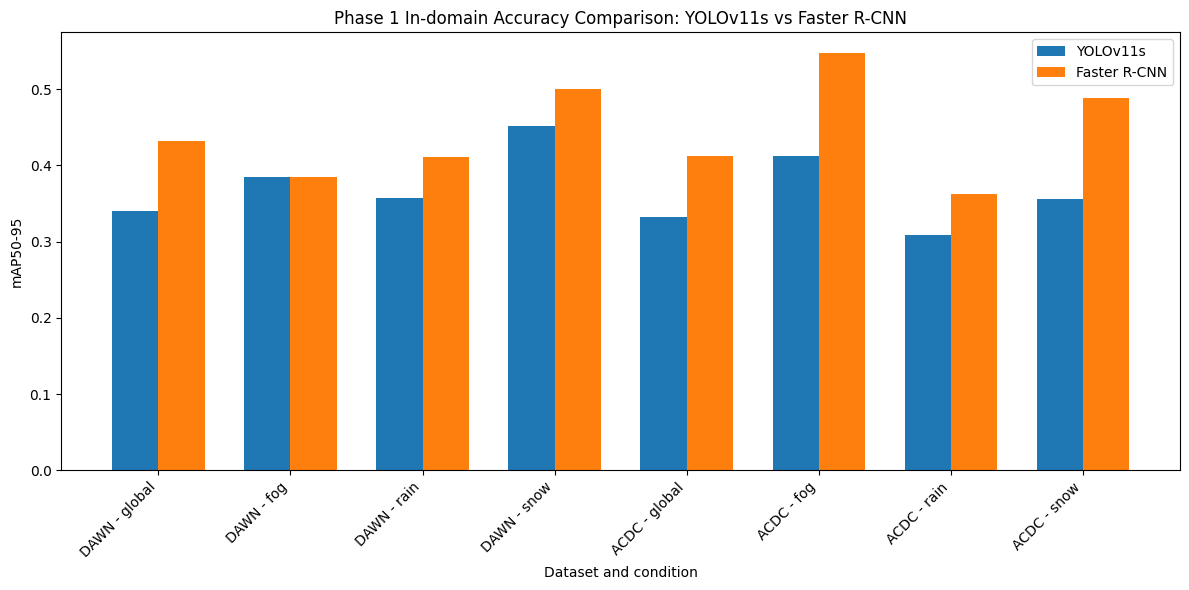

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/figures/phase1_map50_95_comparison.png


In [ ]:
grouped_barplot(
    phase1_df,
    metric="mAP50-95",
    title="Phase 1 In-domain Accuracy Comparison: YOLOv11s vs Faster R-CNN",
    ylabel="mAP50-95",
    filename="phase1_map50_95_comparison.png"
)

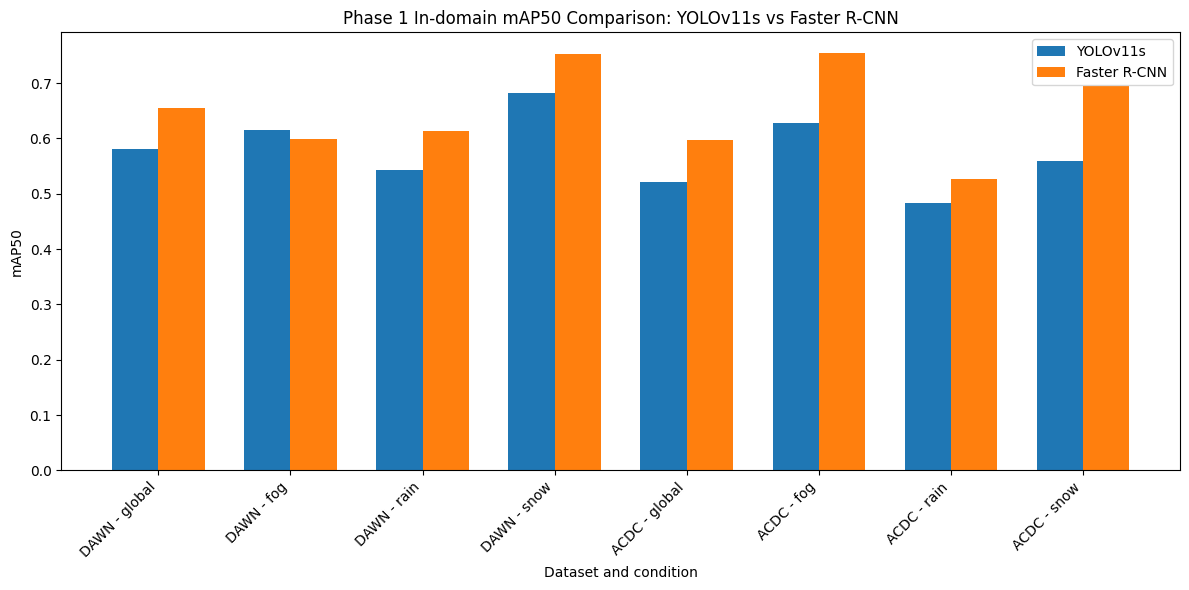

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/figures/phase1_map50_comparison.png


In [ ]:
grouped_barplot(
    phase1_df,
    metric="mAP50",
    title="Phase 1 In-domain mAP50 Comparison: YOLOv11s vs Faster R-CNN",
    ylabel="mAP50",
    filename="phase1_map50_comparison.png"
)

# **Speed comparison**

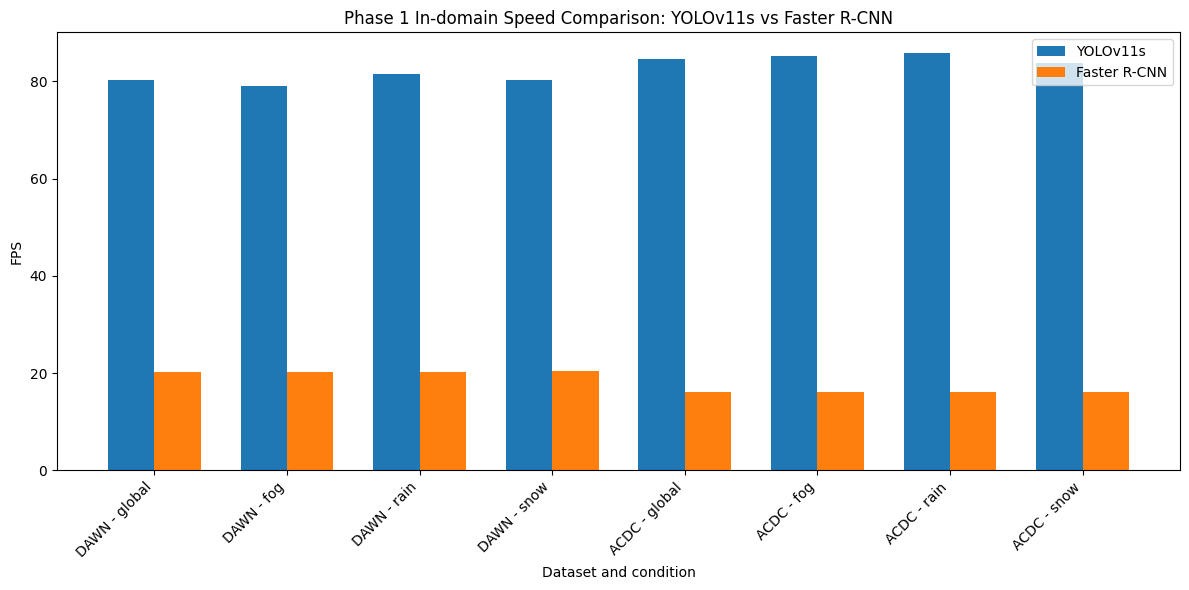

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/figures/phase1_fps_comparison.png


In [ ]:
grouped_barplot(
    phase1_df,
    metric="FPS",
    title="Phase 1 In-domain Speed Comparison: YOLOv11s vs Faster R-CNN",
    ylabel="FPS",
    filename="phase1_fps_comparison.png"
)

# **Speed-Accuracy trade off**

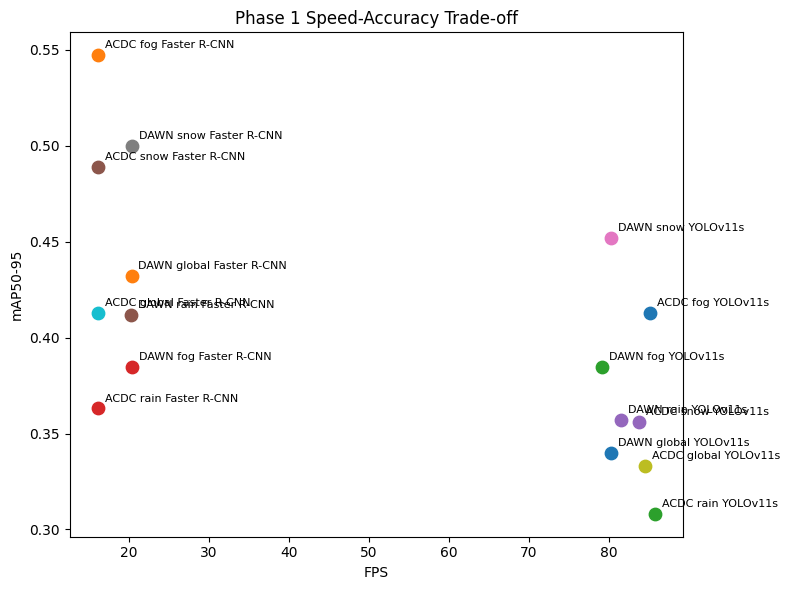

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/figures/phase1_speed_accuracy_tradeoff.png


In [ ]:
if "mAP50-95" in phase1_df.columns and "FPS" in phase1_df.columns:
    plt.figure(figsize=(8, 6))

    for _, row in phase1_df.iterrows():
        if pd.notna(row["mAP50-95"]) and pd.notna(row["FPS"]):
            plt.scatter(row["FPS"], row["mAP50-95"], s=80)
            label = f"{row['dataset']} {row['condition']} {row['model']}"
            plt.annotate(label, (row["FPS"], row["mAP50-95"]), fontsize=8, xytext=(5, 5), textcoords="offset points")

    plt.title("Phase 1 Speed-Accuracy Trade-off")
    plt.xlabel("FPS")
    plt.ylabel("mAP50-95")
    plt.tight_layout()

    output_path = FIGURES_DIR / "phase1_speed_accuracy_tradeoff.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved:", output_path)

# **Dataset difficulty analysis**

In [ ]:
if "mAP50-95" in phase1_df.columns:
    difficulty = phase1_df.groupby(["dataset", "condition"], observed=False)["mAP50-95"].mean().reset_index()
    difficulty = difficulty.rename(columns={"mAP50-95": "mean_mAP50-95_across_models"})

    difficulty_path = TABLES_DIR / "phase1_dataset_difficulty.csv"
    difficulty.to_csv(difficulty_path, index=False)

    display(difficulty)
    print("Saved:", difficulty_path)

,dataset,condition,mean_mAP50-95_across_models
0,DAWN,global,0.385839
1,DAWN,fog,0.384673
2,DAWN,rain,0.384491
3,DAWN,snow,0.475875
4,ACDC,global,0.372861
5,ACDC,fog,0.479954
6,ACDC,rain,0.335606
7,ACDC,snow,0.422423


Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/phase1_global_analysis/tables/phase1_dataset_difficulty.csv


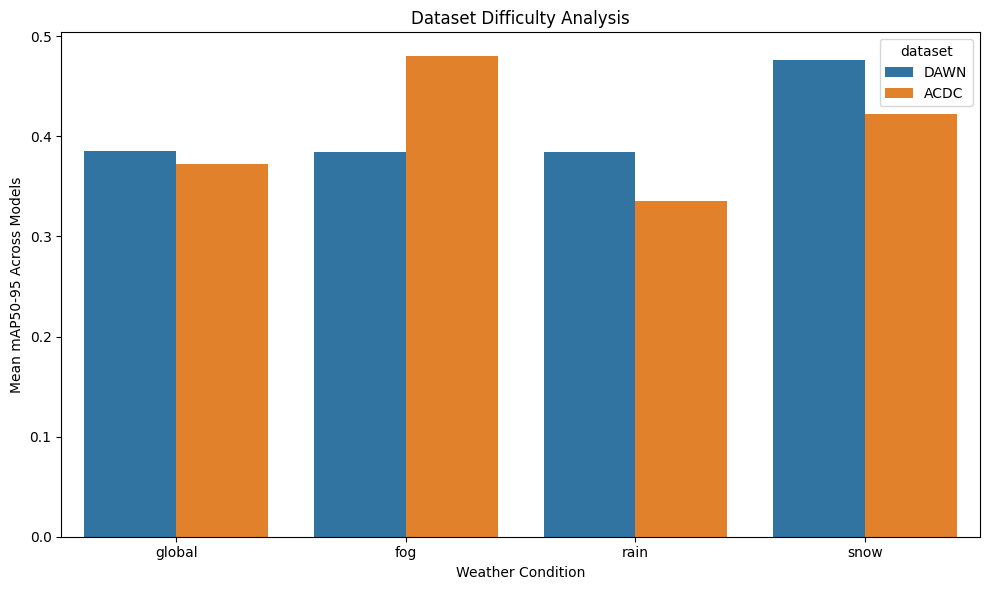

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

difficulty_df = pd.DataFrame({
    "dataset": ["DAWN","DAWN","DAWN","DAWN",
                "ACDC","ACDC","ACDC","ACDC"],

    "condition": ["global","fog","rain","snow",
                  "global","fog","rain","snow"],

    "mean_mAP50-95": [
        0.385839,
        0.384673,
        0.384491,
        0.475875,
        0.372861,
        0.479954,
        0.335606,
        0.422423
    ]
})

plt.figure(figsize=(10,6))

sns.barplot(
    data=difficulty_df,
    x="condition",
    y="mean_mAP50-95",
    hue="dataset"
)

plt.title("Dataset Difficulty Analysis")
plt.ylabel("Mean mAP50-95 Across Models")
plt.xlabel("Weather Condition")

plt.tight_layout()
plt.show()

# **Observations**

In [ ]:
def safe_get(df, dataset, condition, model, metric):
    subset = df[
        (df["dataset"].astype(str) == dataset) &
        (df["condition"].astype(str) == condition) &
        (df["model"].astype(str) == model)
    ]
    if subset.empty or metric not in subset.columns:
        return None
    value = subset[metric].iloc[0]
    return None if pd.isna(value) else value

observations = []

for dataset in dataset_order:
    for condition in condition_order:
        yolo_map = safe_get(phase1_df, dataset, condition, "YOLOv11s", "mAP50-95")
        faster_map = safe_get(phase1_df, dataset, condition, "Faster R-CNN", "mAP50-95")
        yolo_fps = safe_get(phase1_df, dataset, condition, "YOLOv11s", "FPS")
        faster_fps = safe_get(phase1_df, dataset, condition, "Faster R-CNN", "FPS")

        if yolo_map is not None and faster_map is not None:
            winner = "Faster R-CNN" if faster_map > yolo_map else "YOLOv11s"
            diff = abs(faster_map - yolo_map)
            observations.append(
                f"For {dataset} under {condition}, {winner} achieved the higher mAP50-95, with a difference of {diff:.4f}."
            )

        if yolo_fps is not None and faster_fps is not None:
            if faster_fps > 0:
                ratio = yolo_fps / faster_fps
                observations.append(
                    f"For {dataset} under {condition}, YOLOv11s was approximately {ratio:.2f}x faster than Faster R-CNN."
                )

for obs in observations:
    print("-", obs)

obs_path = TABLES_DIR / "phase1_draft_observations.txt"
with open(obs_path, "w") as f:
    for obs in observations:
        f.write("- " + obs + "")

print("Saved:", obs_path)

- For DAWN under global, Faster R-CNN achieved the higher mAP50-95, with a difference of 0.0924.
- For DAWN under global, YOLOv11s was approximately 3.95x faster than Faster R-CNN.
- For DAWN under fog, Faster R-CNN achieved the higher mAP50-95, with a difference of 0.0000.
- For DAWN under fog, YOLOv11s was approximately 3.89x faster than Faster R-CNN.
- For DAWN under rain, Faster R-CNN achieved the higher mAP50-95, with a difference of 0.0545.
- For DAWN under rain, YOLOv11s was approximately 4.03x faster than Faster R-CNN.
- For DAWN under snow, Faster R-CNN achieved the higher mAP50-95, with a difference of 0.0477.
- For DAWN under snow, YOLOv11s was approximately 3.93x faster than Faster R-CNN.
- For ACDC under global, Faster R-CNN achieved the higher mAP50-95, with a difference of 0.0799.
- For ACDC under global, YOLOv11s was approximately 5.25x faster than Faster R-CNN.
- For ACDC under fog, Faster R-CNN achieved the higher mAP50-95, with a difference of 0.1346.
- For ACDC unde

Phase 1 established the in-domain baselines for YOLOv11s and Faster R-CNN on DAWN and ACDC.
The results provide the reference performance obtained when training and testing are performed within the same dataset distribution.
These baselines are necessary before Phase 2, where the same trained models will be evaluated under cross-dataset conditions to quantify the domain gap.

Overall, the Phase 1 results should be interpreted as best-case dataset-specific performance rather than evidence of real-world generalization.
The next phase will test whether the observed speed-accuracy trade-offs remain stable when models are exposed to unseen adverse-weather distributions.